# Data Extraction
Loading the data, column selection, SEQNO duplicate investigation, composite respondent_id fix, and some recoding stubs.

In [0]:
%pip install missingno
%restart_python

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
df = spark.read.table('data_engineering.bronze.brfss_2024').toPandas()

In [0]:
# See column names
print(df.columns.tolist())

['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES2', 'SMALST

In [0]:
!pip install duckdb

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
"""
BRFSS 2024 OLTP Schema Validator (FIXED)
=========================================
Fix applied: SEQNO is not unique — it resets per state.
Solution: respondent_id = _STATE + SEQNO concatenated as integer.

Paste into your Jupyter notebook or run as standalone script.
Install: pip install duckdb
"""

import pandas as pd
import numpy as np
import duckdb

# ─────────────────────────────────────────────────────────────
# STEP 0: Load data
# Comment out if df is already loaded in your notebook
# ─────────────────────────────────────────────────────────────
# XPT_PATH = "/Users/pareeyaporn/Desktop/ADSP 31012 IP01 Data Engineering Platforms for Analytics/Project/LLCP2024.XPT"
# print("Loading BRFSS data...")
# df = pd.read_sas(XPT_PATH, format="xport", encoding="latin1")
# print(f"  Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

# ─────────────────────────────────────────────────────────────
# STEP 1: Select needed columns
# ─────────────────────────────────────────────────────────────
NEEDED = [
    'SEQNO','_STATE','_LLCPWT','IMONTH','IDAY','IYEAR',
    '_METSTAT','_URBSTAT','MSCODE',
    '_SEX','_AGEG5YR','_RACE','_HISPANC','_EDUCAG','_INCOMG1',
    'MARITAL','EMPLOY1','CHILDREN','VETERAN3','PREGNANT',
    'GENHLTH','PHYSHLTH','MENTHLTH','_BMI5','_BMI5CAT',
    'CVDINFR4','CVDSTRK3','DIABETE4','ASTHMA3','ADDEPEV3',
    'CHCCOPD3','HAVARTH4','CHCOCNC1','CHCKDNY2','LSATISFY',
    'EXERANY2','_SMOKER3','ECIGNOW3','DRNKANY6','_RFBING6',
    '_RFDRHV9','AVEDRNK4','MARIJAN1','SSBSUGR2','FIREARM5',
    '_HLTHPL2','PRIMINS2','PERSDOC3','MEDCOST1','CHECKUP1',
    'LASTDEN4','_RFMAM23','_CRVSCRN','_CRCREC3',
    '_FLSHOT7','_PNEUMO3','_AIDTST4','SDHFOOD1','SDHTRNSP',
    'QSTVER','QSTLANG','CELLFON5'
]
available = [c for c in NEEDED if c in df.columns]
missing   = [c for c in NEEDED if c not in df.columns]
raw = df[available].copy()
print(f"Columns found  : {len(available)}")
if missing:
    print(f"Columns missing: {missing}")

# ─────────────────────────────────────────────────────────────
# FIX: Create composite unique respondent_id (STATE + SEQNO)
# SEQNO resets per state — same number appears in all 53 states
# ─────────────────────────────────────────────────────────────
raw['respondent_id'] = (
    raw['_STATE'].astype(int).astype(str) +
    raw['SEQNO'].astype(int).astype(str)
).astype(int)

print(f"\nrespondent_id check:")
print(f"  Total rows      : {len(raw):,}")
print(f"  Unique IDs      : {raw['respondent_id'].nunique():,}")
print(f"  Duplicates      : {len(raw) - raw['respondent_id'].nunique():,}")
assert raw['respondent_id'].nunique() == len(raw), "respondent_id still not unique!"
print(f"  Status          : OK — all unique\n")

# ─────────────────────────────────────────────────────────────
# STEP 2: Recode helpers
# ─────────────────────────────────────────────────────────────
REFUSE = {7, 9, 77, 99, 777, 999, 7777, 9999}

def recode(series, mapping, default=None):
    s = series.copy().astype(float)
    result = s.map(mapping)
    result[s.isin(REFUSE)] = None
    if default is not None:
        result = result.fillna(default)
    return result

def yn(series):
    s = series.copy().astype(float)
    out = pd.Series([None] * len(s), dtype=object)
    out[s == 1] = True
    out[s == 2] = False
    out[s.isin(REFUSE)] = None
    return out

def safe_days(series):
    s = series.copy().astype(float)
    s[s.isin(REFUSE) | s.isin([88])] = np.nan
    s[(s < 0) | (s > 30)] = np.nan
    return s

def safe_bmi(series):
    bmi = series.copy().astype(float) / 100.0
    bmi[(bmi < 10) | (bmi > 100)] = np.nan
    return bmi

def safe_int(series, bad_vals=None, lo=None, hi=None):
    s = series.copy().astype(float)
    if bad_vals: s[s.isin(bad_vals)] = np.nan
    if lo is not None: s[s < lo] = np.nan
    if hi is not None: s[s > hi] = np.nan
    return s

# ─────────────────────────────────────────────────────────────
# STEP 3: Build dimension dataframes
# ─────────────────────────────────────────────────────────────

# ── 3a. STATE ──
FIPS_NAME = {
    1:'Alabama',2:'Alaska',4:'Arizona',5:'Arkansas',6:'California',
    8:'Colorado',9:'Connecticut',10:'Delaware',11:'District of Columbia',
    12:'Florida',13:'Georgia',15:'Hawaii',16:'Idaho',17:'Illinois',
    18:'Indiana',19:'Iowa',20:'Kansas',21:'Kentucky',22:'Louisiana',
    23:'Maine',24:'Maryland',25:'Massachusetts',26:'Michigan',
    27:'Minnesota',28:'Mississippi',29:'Missouri',30:'Montana',
    31:'Nebraska',32:'Nevada',33:'New Hampshire',34:'New Jersey',
    35:'New Mexico',36:'New York',37:'North Carolina',38:'North Dakota',
    39:'Ohio',40:'Oklahoma',41:'Oregon',42:'Pennsylvania',
    44:'Rhode Island',45:'South Carolina',46:'South Dakota',
    47:'Tennessee',48:'Texas',49:'Utah',50:'Vermont',51:'Virginia',
    53:'Washington',54:'West Virginia',55:'Wisconsin',56:'Wyoming',
    66:'Guam',72:'Puerto Rico',78:'Virgin Islands'
}
FIPS_ABBR = {
    1:'AL',2:'AK',4:'AZ',5:'AR',6:'CA',8:'CO',9:'CT',10:'DE',11:'DC',
    12:'FL',13:'GA',15:'HI',16:'ID',17:'IL',18:'IN',19:'IA',20:'KS',
    21:'KY',22:'LA',23:'ME',24:'MD',25:'MA',26:'MI',27:'MN',28:'MS',
    29:'MO',30:'MT',31:'NE',32:'NV',33:'NH',34:'NJ',35:'NM',36:'NY',
    37:'NC',38:'ND',39:'OH',40:'OK',41:'OR',42:'PA',44:'RI',45:'SC',
    46:'SD',47:'TN',48:'TX',49:'UT',50:'VT',51:'VA',53:'WA',54:'WV',
    55:'WI',56:'WY',66:'GU',72:'PR',78:'VI'
}
ABBR_REGION = {
    'CT':'Northeast','ME':'Northeast','MA':'Northeast','NH':'Northeast',
    'RI':'Northeast','VT':'Northeast','NJ':'Northeast','NY':'Northeast',
    'PA':'Northeast','IL':'Midwest','IN':'Midwest','MI':'Midwest',
    'OH':'Midwest','WI':'Midwest','IA':'Midwest','KS':'Midwest',
    'MN':'Midwest','MO':'Midwest','NE':'Midwest','ND':'Midwest',
    'SD':'Midwest','DE':'South','FL':'South','GA':'South','MD':'South',
    'NC':'South','SC':'South','VA':'South','DC':'South','WV':'South',
    'AL':'South','KY':'South','MS':'South','TN':'South','AR':'South',
    'LA':'South','OK':'South','TX':'South','AZ':'West','CO':'West',
    'ID':'West','MT':'West','NV':'West','NM':'West','UT':'West',
    'WY':'West','AK':'West','CA':'West','HI':'West','OR':'West',
    'WA':'West','GU':'West','PR':'South','VI':'South'
}
ABBR_DIVISION = {
    'CT':'New England','ME':'New England','MA':'New England',
    'NH':'New England','RI':'New England','VT':'New England',
    'NJ':'Middle Atlantic','NY':'Middle Atlantic','PA':'Middle Atlantic',
    'IL':'East North Central','IN':'East North Central','MI':'East North Central',
    'OH':'East North Central','WI':'East North Central',
    'IA':'West North Central','KS':'West North Central','MN':'West North Central',
    'MO':'West North Central','NE':'West North Central','ND':'West North Central',
    'SD':'West North Central','DE':'South Atlantic','FL':'South Atlantic',
    'GA':'South Atlantic','MD':'South Atlantic','NC':'South Atlantic',
    'SC':'South Atlantic','VA':'South Atlantic','DC':'South Atlantic',
    'WV':'South Atlantic','AL':'East South Central','KY':'East South Central',
    'MS':'East South Central','TN':'East South Central','AR':'West South Central',
    'LA':'West South Central','OK':'West South Central','TX':'West South Central',
    'AZ':'Mountain','CO':'Mountain','ID':'Mountain','MT':'Mountain',
    'NV':'Mountain','NM':'Mountain','UT':'Mountain','WY':'Mountain',
    'AK':'Pacific','CA':'Pacific','HI':'Pacific','OR':'Pacific',
    'WA':'Pacific','GU':'Pacific','PR':'Caribbean','VI':'Caribbean'
}

state_rows = []
for sid in sorted(raw['_STATE'].dropna().unique()):
    sid_int = int(sid)
    code    = FIPS_ABBR.get(sid_int, '??')
    state_rows.append({
        'state_id':   sid_int,
        'state_code': code,
        'state_name': FIPS_NAME.get(sid_int, 'Unknown'),
        'region':     ABBR_REGION.get(code, 'Unknown'),
        'division':   ABBR_DIVISION.get(code, 'Unknown'),
    })
df_state = pd.DataFrame(state_rows)
print(f"state            : {len(df_state):>7,} rows")

# ── 3b. SURVEY_META ──
lang_map  = {1:'English', 2:'Spanish', 3:'Other'}
phone_map = {1:'Landline', 2:'Cell only', 3:'Both'}

sm = raw[['QSTVER','QSTLANG','CELLFON5','IYEAR']].copy()
sm['questionnaire_ver'] = sm['QSTVER'].astype(str).str.strip().str[:10]
sm['language']          = recode(sm['QSTLANG'],  lang_map,  'Other')
sm['phone_type']        = recode(sm['CELLFON5'], phone_map, 'Unknown')
sm['interview_year']    = sm['IYEAR'].fillna(2024).astype(int)
df_survey = (sm[['questionnaire_ver','language','phone_type','interview_year']]
             .drop_duplicates().reset_index(drop=True))
df_survey.insert(0, 'survey_id', df_survey.index + 1)
sm_lookup = sm.merge(df_survey,
                     on=['questionnaire_ver','language','phone_type','interview_year'],
                     how='left')['survey_id']
print(f"survey_meta      : {len(df_survey):>7,} rows")

# ── 3c. GEOGRAPHIC ──
metro_map = {1:'Metropolitan', 2:'Non-metropolitan'}
urban_map = {1:'Urban', 2:'Rural'}

df_geo = pd.DataFrame({
    'state_id':    raw['_STATE'].astype(float).astype('Int64'),
    'metro_status':recode(raw['_METSTAT'], metro_map, 'Unknown'),
    'urban_rural': recode(raw['_URBSTAT'], urban_map, 'Unknown'),
    'mscode':      raw['MSCODE'].where(raw['MSCODE'].notna(), None),
}).reset_index(drop=True)
df_geo.insert(0, 'geo_id', df_geo.index + 1)
print(f"geographic       : {len(df_geo):>7,} rows")

# ── 3d. DEMOGRAPHICS ──
sex_map     = {1:'Male', 2:'Female'}
age_map     = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
               6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
               11:'70-74',12:'75-79',13:'80+',14:'80+'}
race_map    = {1:'White',2:'Black',3:'American Indian/Alaska Native',
               4:'Asian',5:'Native Hawaiian/Pacific Islander',
               6:'Other race',7:'Multiracial',8:'Hispanic'}
hisp_map    = {1:'Yes', 2:'No'}
educ_map    = {1:'< High school',2:'High school grad',
               3:'Some college',4:'College grad'}
income_map  = {1:'<$15,000',2:'$15,000-$25,000',3:'$25,000-$35,000',
               4:'$35,000-$50,000',5:'$50,000-$100,000',
               6:'$100,000-$200,000',7:'$200,000+'}
marital_map = {1:'Married',2:'Divorced',3:'Widowed',
               4:'Separated',5:'Never married',6:'Partnered'}
employ_map  = {1:'Employed',2:'Self-employed',3:'Out of work 1yr+',
               4:'Out of work <1yr',5:'Homemaker',
               6:'Student',7:'Retired',8:'Unable to work'}

def safe_children(s):
    s2 = s.copy().astype(float)
    s2[s2.isin([88, 99])] = 0
    s2[(s2 < 0) | (s2 > 87)] = 0
    return s2.fillna(0).astype(int)

df_demo = pd.DataFrame({
    'sex':            recode(raw['_SEX'],     sex_map,    'Unknown'),
    'age_group':      recode(raw['_AGEG5YR'], age_map,    'Unknown'),
    'race':           recode(raw['_RACE'],    race_map,   'Unknown'),
    'hispanic':       recode(raw['_HISPANC'], hisp_map,   'Unknown'),
    'education':      recode(raw['_EDUCAG'],  educ_map,   'Unknown'),
    'income_group':   recode(raw['_INCOMG1'], income_map, 'Unknown'),
    'marital_status': recode(raw['MARITAL'],  marital_map, None),
    'employment':     recode(raw['EMPLOY1'],  employ_map,  None),
    'num_children':   safe_children(raw['CHILDREN']),
    'veteran':        yn(raw['VETERAN3']),
    'pregnant':       yn(raw['PREGNANT']).fillna(False),
})
df_demo.insert(0, 'demo_id', df_demo.index + 1)
print(f"demographics     : {len(df_demo):>7,} rows")

# ── 3e. HEALTH_STATUS ──
health_map = {1:'Excellent',2:'Very good',3:'Good',4:'Fair',5:'Poor'}
bmicat_map = {1:'Underweight',2:'Normal weight',3:'Overweight',4:'Obese'}
satisf_map = {1:'Very satisfied',2:'Satisfied',
              3:'Dissatisfied',4:'Very dissatisfied'}

df_health = pd.DataFrame({
    'general_health':        recode(raw['GENHLTH'],  health_map, None),
    'phys_unhealthy_days':   safe_days(raw['PHYSHLTH']),
    'mental_unhealthy_days': safe_days(raw['MENTHLTH']),
    'bmi':                   safe_bmi(raw['_BMI5']),
    'bmi_category':          recode(raw['_BMI5CAT'], bmicat_map, None),
    'heart_attack':          yn(raw['CVDINFR4']),
    'stroke':                yn(raw['CVDSTRK3']),
    'diabetes':              yn(raw['DIABETE4']),
    'asthma':                yn(raw['ASTHMA3']),
    'depression':            yn(raw['ADDEPEV3']),
    'copd':                  yn(raw['CHCCOPD3']),
    'arthritis':             yn(raw['HAVARTH4']),
    'cancer':                yn(raw['CHCOCNC1']),
    'kidney_disease':        yn(raw['CHCKDNY2']),
    'life_satisfaction':     recode(raw['LSATISFY'], satisf_map, None),
})
df_health.insert(0, 'health_id', df_health.index + 1)
print(f"health_status    : {len(df_health):>7,} rows")

# ── 3f. BEHAVIORS ──
smoke_map  = {1:'Never',2:'Every day',3:'Some days',4:'Former'}
ecig_map   = {1:'Never',2:'Former',3:'Current'}
ssbdrk_map = {1:'Never',2:'< 1/day',3:'1/day',4:'2+/day'}

df_beh = pd.DataFrame({
    'exercise':           yn(raw['EXERANY2']),
    'smoke_status':       recode(raw['_SMOKER3'], smoke_map,  None),
    'ecig_use':           recode(raw['ECIGNOW3'], ecig_map,   None),
    'any_alcohol':        yn(raw['DRNKANY6']),
    'binge_drinking':     yn(raw['_RFBING6']),
    'heavy_drinker':      yn(raw['_RFDRHV9']),
    'avg_drinks_per_day': safe_int(raw['AVEDRNK4'], bad_vals=[77,99], lo=0, hi=76),
    'marijuana_use':      yn(raw['MARIJAN1']),
    'sugary_drinks':      recode(raw['SSBSUGR2'], ssbdrk_map, None),
    'firearm_home':       yn(raw['FIREARM5']),
    'cluster_label':      None,
})
df_beh.insert(0, 'behavior_id', df_beh.index + 1)
print(f"behaviors        : {len(df_beh):>7,} rows")

# ── 3g. PREVENTIVE_CARE ──
ins_map   = {1:'Private',2:'Medicare',3:'Medicaid',
             4:'Military',5:'None',6:'Other'}
visit_map = {1:'Within past year',2:'1-2 years ago',
             3:'2-5 years ago',4:'5+ years ago',8:'Never'}

df_care = pd.DataFrame({
    'has_insurance':     yn(raw['_HLTHPL2']),
    'insurance_type':    recode(raw['PRIMINS2'], ins_map,   None),
    'has_pcp':           yn(raw['PERSDOC3']),
    'cost_barrier':      yn(raw['MEDCOST1']),
    'last_checkup':      recode(raw['CHECKUP1'], visit_map, None),
    'last_dental':       recode(raw['LASTDEN4'], visit_map, None),
    'mammogram_2yr':     yn(raw['_RFMAM23']),
    'cervical_screen':   yn(raw['_CRVSCRN']),
    'colorectal_screen': yn(raw['_CRCREC3']),
    'flu_shot':          yn(raw['_FLSHOT7']),
    'pneumo_vaccine':    yn(raw['_PNEUMO3']),
    'hiv_test':          yn(raw['_AIDTST4']),
    'food_insecure':     yn(raw['SDHFOOD1']),
    'transport_barrier': yn(raw['SDHTRNSP']),
})
df_care.insert(0, 'care_id', df_care.index + 1)
print(f"preventive_care  : {len(df_care):>7,} rows")

# ── 3h. RESPONDENT (uses fixed respondent_id) ──
def make_date(row):
    try:
        m = int(row['IMONTH']) if not pd.isna(row['IMONTH']) else 1
        d = int(row['IDAY'])   if not pd.isna(row['IDAY'])   else 1
        y = int(row['IYEAR'])  if not pd.isna(row['IYEAR'])  else 2024
        return f"{y:04d}-{m:02d}-{d:02d}"
    except:
        return "2024-01-01"

print("Building respondent table...")
df_resp = pd.DataFrame({
    'respondent_id':  raw['respondent_id'],          # ← composite key (STATE+SEQNO)
    'state_id':       raw['_STATE'].astype(float).astype('Int64'),
    'geo_id':         df_geo['geo_id'],
    'demo_id':        df_demo['demo_id'],
    'health_id':      df_health['health_id'],
    'behavior_id':    df_beh['behavior_id'],
    'care_id':        df_care['care_id'],
    'survey_id':      sm_lookup.values,
    'llcpwt':         raw['_LLCPWT'].astype(float),
    'interview_date': raw[['IMONTH','IDAY','IYEAR']].apply(make_date, axis=1),
})
print(f"respondent       : {len(df_resp):>7,} rows\n")

# ─────────────────────────────────────────────────────────────
# STEP 4: Load into DuckDB
# ─────────────────────────────────────────────────────────────
print("=" * 60)
print("Loading into DuckDB (in-memory)...")
print("=" * 60)

con = duckdb.connect()

con.register("df_state",   df_state)
con.register("df_survey",  df_survey)
con.register("df_geo",     df_geo)
con.register("df_demo",    df_demo)
con.register("df_health",  df_health)
con.register("df_beh",     df_beh)
con.register("df_care",    df_care)
con.register("df_resp",    df_resp)

ddl_steps = [
    ("state",           "CREATE TABLE state           AS SELECT * FROM df_state"),
    ("survey_meta",     "CREATE TABLE survey_meta     AS SELECT * FROM df_survey"),
    ("geographic",      "CREATE TABLE geographic      AS SELECT * FROM df_geo"),
    ("demographics",    "CREATE TABLE demographics    AS SELECT * FROM df_demo"),
    ("health_status",   "CREATE TABLE health_status   AS SELECT * FROM df_health"),
    ("behaviors",       "CREATE TABLE behaviors       AS SELECT * FROM df_beh"),
    ("preventive_care", "CREATE TABLE preventive_care AS SELECT * FROM df_care"),
    ("respondent",      "CREATE TABLE respondent      AS SELECT * FROM df_resp"),
]

for tname, ddl in ddl_steps:
    try:
        con.execute(ddl)
        n = con.execute(f"SELECT COUNT(*) FROM {tname}").fetchone()[0]
        print(f"  [OK]  {tname:<20} {n:,} rows")
    except Exception as e:
        print(f"  [FAIL] {tname:<20} {e}")

# ─────────────────────────────────────────────────────────────
# STEP 5: Validation checks
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RUNNING VALIDATION CHECKS")
print("=" * 60)

checks = []

def check(label, query, expect_zero=True):
    try:
        val = con.execute(query).fetchone()[0]
        if expect_zero:
            status = "PASS" if val == 0 else "FAIL"
            detail = "no violations" if val == 0 else f"{val:,} violations"
        else:
            status = "PASS"
            detail = f"{val:,} rows"
        checks.append((label, status, detail))
    except Exception as e:
        checks.append((label, "ERROR", str(e)[:60]))

# Row counts
check("state rows",           "SELECT COUNT(*) FROM state",           expect_zero=False)
check("survey_meta rows",     "SELECT COUNT(*) FROM survey_meta",     expect_zero=False)
check("geographic rows",      "SELECT COUNT(*) FROM geographic",      expect_zero=False)
check("demographics rows",    "SELECT COUNT(*) FROM demographics",    expect_zero=False)
check("health_status rows",   "SELECT COUNT(*) FROM health_status",   expect_zero=False)
check("behaviors rows",       "SELECT COUNT(*) FROM behaviors",       expect_zero=False)
check("preventive_care rows", "SELECT COUNT(*) FROM preventive_care", expect_zero=False)
check("respondent rows",      "SELECT COUNT(*) FROM respondent",      expect_zero=False)

# PK uniqueness
check("respondent PK unique", "SELECT COUNT(*)-COUNT(DISTINCT respondent_id) FROM respondent")
check("state PK unique",      "SELECT COUNT(*)-COUNT(DISTINCT state_id) FROM state")

# FK integrity
check("FK: respondent → state",
      "SELECT COUNT(*) FROM respondent r LEFT JOIN state s ON r.state_id=s.state_id WHERE s.state_id IS NULL")
check("FK: respondent → geographic",
      "SELECT COUNT(*) FROM respondent r LEFT JOIN geographic g ON r.geo_id=g.geo_id WHERE g.geo_id IS NULL")
check("FK: respondent → demographics",
      "SELECT COUNT(*) FROM respondent r LEFT JOIN demographics d ON r.demo_id=d.demo_id WHERE d.demo_id IS NULL")
check("FK: respondent → health_status",
      "SELECT COUNT(*) FROM respondent r LEFT JOIN health_status h ON r.health_id=h.health_id WHERE h.health_id IS NULL")
check("FK: respondent → behaviors",
      "SELECT COUNT(*) FROM respondent r LEFT JOIN behaviors b ON r.behavior_id=b.behavior_id WHERE b.behavior_id IS NULL")
check("FK: respondent → preventive_care",
      "SELECT COUNT(*) FROM respondent r LEFT JOIN preventive_care c ON r.care_id=c.care_id WHERE c.care_id IS NULL")
check("FK: respondent → survey_meta",
      "SELECT COUNT(*) FROM respondent r LEFT JOIN survey_meta s ON r.survey_id=s.survey_id WHERE s.survey_id IS NULL")
check("FK: geographic → state",
      "SELECT COUNT(*) FROM geographic g LEFT JOIN state s ON g.state_id=s.state_id WHERE s.state_id IS NULL")

# NOT NULL critical fields
check("respondent_id not null", "SELECT COUNT(*) FROM respondent WHERE respondent_id IS NULL")
check("llcpwt not null",        "SELECT COUNT(*) FROM respondent WHERE llcpwt IS NULL")
check("state_id not null",      "SELECT COUNT(*) FROM respondent WHERE state_id IS NULL")

# CHECK constraints
check("llcpwt > 0",
      "SELECT COUNT(*) FROM respondent WHERE llcpwt <= 0")
check("phys_unhealthy_days 0-30",
      "SELECT COUNT(*) FROM health_status WHERE phys_unhealthy_days NOT BETWEEN 0 AND 30 AND phys_unhealthy_days IS NOT NULL")
check("mental_unhealthy_days 0-30",
      "SELECT COUNT(*) FROM health_status WHERE mental_unhealthy_days NOT BETWEEN 0 AND 30 AND mental_unhealthy_days IS NOT NULL")
check("BMI range 10-100",
      "SELECT COUNT(*) FROM health_status WHERE bmi NOT BETWEEN 10 AND 100 AND bmi IS NOT NULL")
check("avg_drinks_per_day 0-76",
      "SELECT COUNT(*) FROM behaviors WHERE avg_drinks_per_day NOT BETWEEN 0 AND 76 AND avg_drinks_per_day IS NOT NULL")
check("num_children 0-87",
      "SELECT COUNT(*) FROM demographics WHERE num_children NOT BETWEEN 0 AND 87 AND num_children IS NOT NULL")
check("sex values valid",
      "SELECT COUNT(*) FROM demographics WHERE sex NOT IN ('Male','Female','Unknown') AND sex IS NOT NULL")
check("general_health values valid",
      "SELECT COUNT(*) FROM health_status WHERE general_health NOT IN ('Excellent','Very good','Good','Fair','Poor') AND general_health IS NOT NULL")
check("smoke_status values valid",
      "SELECT COUNT(*) FROM behaviors WHERE smoke_status NOT IN ('Never','Every day','Some days','Former') AND smoke_status IS NOT NULL")
check("region values valid",
      "SELECT COUNT(*) FROM state WHERE region NOT IN ('Northeast','Midwest','South','West','Unknown')")
check("interview_year valid",
      "SELECT COUNT(*) FROM survey_meta WHERE interview_year NOT BETWEEN 2020 AND 2030")
check("state has 53 territories",
      "SELECT ABS(COUNT(*) - 53) FROM state")
check("respondent count matches source",
      "SELECT ABS(COUNT(*) - 457670) FROM respondent")

# ─────────────────────────────────────────────────────────────
# STEP 6: Print final report
# ─────────────────────────────────────────────────────────────
passed = sum(1 for _, s, _ in checks if s == "PASS")
failed = sum(1 for _, s, _ in checks if s == "FAIL")
errors = sum(1 for _, s, _ in checks if s == "ERROR")

print(f"\n{'Check':<45} {'Status':<8} Detail")
print("─" * 75)
for label, status, detail in checks:
    icon = "✓" if status == "PASS" else ("✗" if status == "FAIL" else "!")
    print(f"  {icon} {label:<43} {status:<8} {detail}")

print("─" * 75)
print(f"\n  {len(checks)} checks  —  {passed} PASS | {failed} FAIL | {errors} ERROR\n")

if failed == 0 and errors == 0:
    print("  ✓ All checks passed — schema is ready for Snowflake!\n")
else:
    print("  ✗ Fix the issues above before loading into Snowflake.\n")

con.close()

Columns found  : 62

respondent_id check:
  Total rows      : 457,670
  Unique IDs      : 457,670
  Duplicates      : 0
  Status          : OK — all unique

state            :      53 rows
survey_meta      :      31 rows
geographic       : 457,670 rows
demographics     : 457,670 rows
health_status    : 457,670 rows
behaviors        : 457,670 rows
preventive_care  : 457,670 rows
Building respondent table...
respondent       : 457,670 rows

Loading into DuckDB (in-memory)...
  [OK]  state                53 rows
  [OK]  survey_meta          31 rows
  [OK]  geographic           457,670 rows
  [OK]  demographics         457,670 rows
  [OK]  health_status        457,670 rows
  [OK]  behaviors            457,670 rows
  [OK]  preventive_care      457,670 rows
  [OK]  respondent           457,670 rows

RUNNING VALIDATION CHECKS

Check                                         Status   Detail
───────────────────────────────────────────────────────────────────────────
  ✓ state rows                

In [0]:
# ── Investigate the duplicate SEQNO issue ──────────────────

# 1. Check how many unique SEQNOs exist
print("Total rows:        ", len(raw))
print("Unique SEQNOs:     ", raw['SEQNO'].nunique())
print("Duplicate SEQNOs:  ", len(raw) - raw['SEQNO'].nunique())

# 2. See what a duplicate looks like
dupes = raw[raw['SEQNO'].duplicated(keep=False)].sort_values('SEQNO')
print("\nSample duplicate SEQNOs:")
print(dupes[['SEQNO','_STATE','IMONTH','IDAY','IYEAR']].head(10))

# 3. Check if same SEQNO appears across different states
print("\nDo duplicates span different states?")
print(dupes.groupby('SEQNO')['_STATE'].nunique().value_counts())

Total rows:         457670
Unique SEQNOs:      43913
Duplicate SEQNOs:   413757

Sample duplicate SEQNOs:
             SEQNO _STATE IMONTH IDAY IYEAR
0       2024000001     01     02   28  2024
447170  2024000001     56     06   21  2024
56174   2024000001     11     07   31  2024
239495  2024000001     32     07   06  2024
136082  2024000001     21     06   29  2024
61788   2024000001     12     03   05  2024
209506  2024000001     28     02   28  2024
363695  2024000001     48     05   16  2024
437331  2024000001     55     03   13  2024
5092    2024000001     02     01   17  2024

Do duplicates span different states?
2     10601
4      1366
53     1348
51     1002
22      912
46      796
18      750
3       737
15      708
16      695
12      561
13      522
40      488
9       380
32      368
50      324
36      320
52      312
33      292
7       268
39      252
49      212
21      206
48      195
42      187
30      180
11      164
23      161
26      150
10      147
38      123


KELLY SECTION

# EDA
Distributions, missing values visualization, weighted vs unweighted comparisons, outcome prevalence, geographic breakdown, correlations, and demographic cross-tabs

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})
sns.set_theme(style="whitegrid", palette="muted")

# ── Variable groups (from your NEEDED list) ──────────────────
DEMO_VARS      = ['_SEX', '_AGEG5YR', '_RACE', '_HISPANC', '_EDUCAG',
                  '_INCOMG1', 'MARITAL', 'EMPLOY1', 'VETERAN3']

OUTCOME_VARS   = ['CVDINFR4', 'CVDSTRK3', 'DIABETE4', 'ASTHMA3',
                  'ADDEPEV3', 'CHCCOPD3', 'HAVARTH4', 'CHCOCNC1',
                  'CHCKDNY2']

BEHAVIOR_VARS  = ['EXERANY2', '_SMOKER3', 'ECIGNOW3', 'DRNKANY6',
                  '_RFBING6', '_RFDRHV9', 'MARIJAN1', 'SSBSUGR2',
                  'FIREARM5']

HEALTH_VARS    = ['GENHLTH', 'PHYSHLTH', 'MENTHLTH', '_BMI5CAT']

HEALTHCARE_VARS = ['_HLTHPL2', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1',
                   'CHECKUP1', 'LASTDEN4']

WEIGHT_COL     = '_LLCPWT'

# Friendly labels for outcomes
OUTCOME_LABELS = {
    'CVDINFR4': 'Heart Attack',
    'CVDSTRK3': 'Stroke',
    'DIABETE4': 'Diabetes',
    'ASTHMA3':  'Asthma',
    'ADDEPEV3': 'Depression',
    'CHCCOPD3': 'COPD',
    'HAVARTH4': 'Arthritis',
    'CHCOCNC1': 'Cancer',
    'CHCKDNY2': 'Kidney Disease',
}

# BRFSS "Yes" code for most binary disease questions is 1
YES_CODE = 1.0


## Section 1: Data Overview

In [0]:
print(f"\nShape         : {raw.shape[0]:,} rows × {raw.shape[1]} columns")
print(f"Memory usage  : {raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nColumn dtypes:\n{raw.dtypes.value_counts()}")
print(f"\nSample rows:")
display(raw.head(3))

print(f"\nDescriptive stats (numeric):")
display(raw.describe().T[['count','mean','std','min','50%','max']])


Shape         : 457,670 rows × 63 columns
Memory usage  : 1516.9 MB

Column dtypes:
object    62
int64      1
dtype: int64

Sample rows:


SEQNO,_STATE,_LLCPWT,IMONTH,IDAY,IYEAR,_METSTAT,_URBSTAT,MSCODE,_SEX,_AGEG5YR,_RACE,_HISPANC,_EDUCAG,_INCOMG1,MARITAL,EMPLOY1,CHILDREN,VETERAN3,PREGNANT,GENHLTH,PHYSHLTH,MENTHLTH,_BMI5,_BMI5CAT,CVDINFR4,CVDSTRK3,DIABETE4,ASTHMA3,ADDEPEV3,CHCCOPD3,HAVARTH4,CHCOCNC1,CHCKDNY2,LSATISFY,EXERANY2,_SMOKER3,ECIGNOW3,DRNKANY6,_RFBING6,_RFDRHV9,AVEDRNK4,MARIJAN1,SSBSUGR2,FIREARM5,_HLTHPL2,PRIMINS2,PERSDOC3,MEDCOST1,CHECKUP1,LASTDEN4,_RFMAM23,_CRVSCRN,_CRCREC3,_FLSHOT7,_PNEUMO3,_AIDTST4,SDHFOOD1,SDHTRNSP,QSTVER,QSTLANG,CELLFON5,respondent_id
2024000001,01,261.525511,02,28,2024,1,1,1,2,12,1,2,2,9,3,7,88,2,null,3,02,88,2249,2,2,2,3,2,2,2,1,2,2,1,1,4,1,2,1,1,null,null,null,null,1,03,2,2,1,1,1,1,null,1,2,2,5,2,10,01,null,12024000001
2024000002,01,307.169688,02,21,2024,1,1,1,1,13,1,2,4,7,1,7,88,1,null,1,88,88,2583,3,2,2,3,2,2,2,1,2,2,1,1,3,1,2,1,1,null,null,null,null,1,03,1,2,1,1,null,null,null,1,1,2,5,2,10,01,null,12024000002
2024000003,01,2939.86281,02,21,2024,2,1,5,1,08,1,2,3,9,6,1,88,1,null,2,30,88,2253,2,2,2,3,2,2,2,1,2,2,1,1,1,1,1,2,1,02,null,null,null,1,01,3,1,4,4,null,null,3,null,null,2,5,2,10,01,null,12024000003



Descriptive stats (numeric):


count,mean,std,min,50%,max
457670.0,3.102593728446628E11,1.59393645671409E11,1.2024000001E10,3.120240024375E11,7.82024001348E11


## Section 2: Missing Values


45 columns have missing values
  column  pct_missing
  MSCODE    82.514912
PREGNANT    82.222344
FIREARM5    76.911967
SSBSUGR2    74.741189
MARIJAN1    70.102476
_FLSHOT7    60.813687
_PNEUMO3    60.813687
_RFMAM23    58.758713
SDHTRNSP    55.921516
SDHFOOD1    55.764197
LSATISFY    55.477964
_CRVSCRN    55.001857
AVEDRNK4    54.082417
_CRCREC3    50.259576
CELLFON5    17.858064
_AIDTST4     9.502917
_BMI5CAT     9.403500
   _BMI5     9.403500
ECIGNOW3     6.702646
_URBSTAT     3.195097
_METSTAT     3.195097
CHILDREN     1.224900
 EMPLOY1     0.721699
VETERAN3     0.269845
 MARITAL     0.001966
CHCCOPD3     0.001529
MEDCOST1     0.001311
CHCKDNY2     0.001311
CHCOCNC1     0.001092
HAVARTH4     0.001092
ADDEPEV3     0.001092
 GENHLTH     0.001092
PHYSHLTH     0.001092
DIABETE4     0.000874
CVDSTRK3     0.000655
EXERANY2     0.000655
PERSDOC3     0.000655
MENTHLTH     0.000655
 ASTHMA3     0.000655
PRIMINS2     0.000655
CVDINFR4     0.000437
LASTDEN4     0.000437
CHECKUP1     0.000437


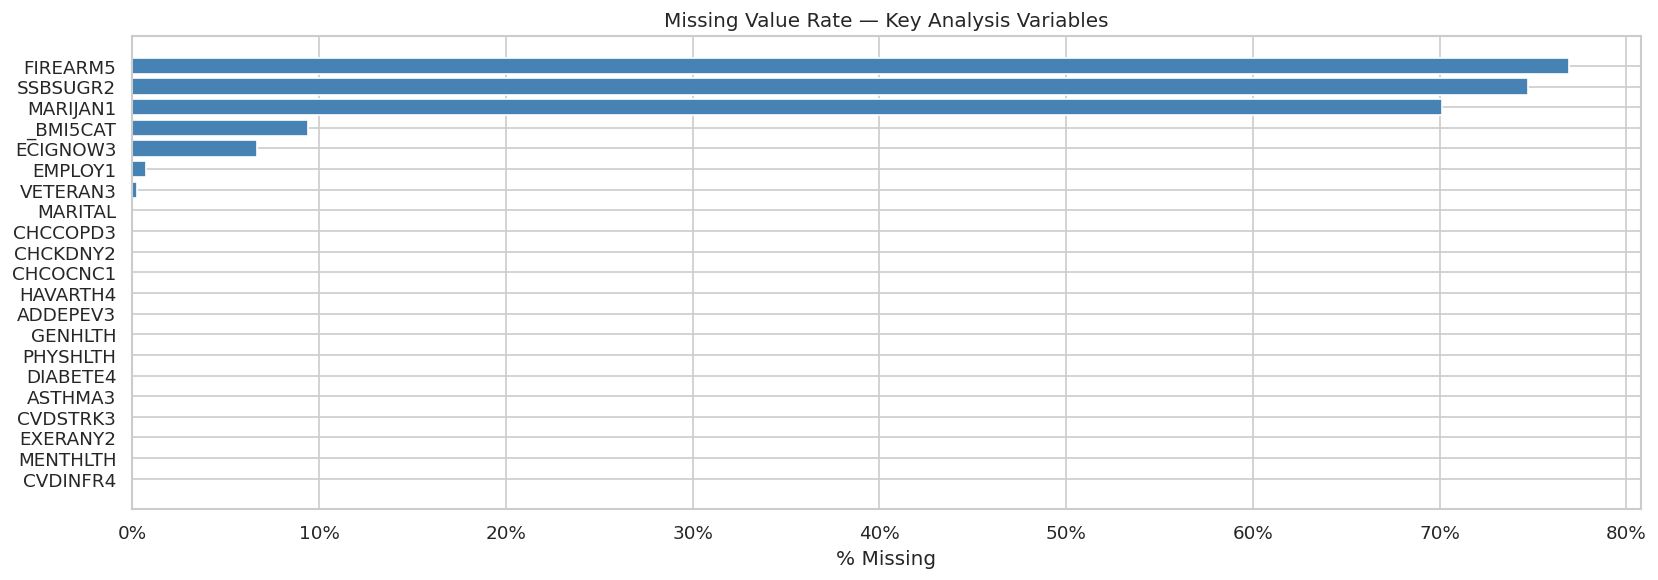

In [0]:
# 2a. Overall missing rate per column
miss = (raw.isnull().sum() / len(raw) * 100).sort_values(ascending=False)
miss_df = miss[miss > 0].reset_index()
miss_df.columns = ['column', 'pct_missing']
print(f"\n{len(miss_df)} columns have missing values")
print(miss_df.to_string(index=False))

# 2b. Bar chart of missing %
fig, ax = plt.subplots(figsize=(14, 5))
key_cols = [c for c in OUTCOME_VARS + BEHAVIOR_VARS + DEMO_VARS + HEALTH_VARS
            if c in miss_df['column'].values]
subset = miss_df[miss_df['column'].isin(key_cols)].sort_values('pct_missing', ascending=True)
ax.barh(subset['column'], subset['pct_missing'], color='steelblue')
ax.set_xlabel("% Missing")
ax.set_title("Missing Value Rate — Key Analysis Variables")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()



* The dataset has 457,670 respondents across 63 selected columns, using 314MB of memory.
* 43 of 63 columns have some missing values, but most core outcome and behavior variables are nearly complete (<1% missing).
* The high-missingness columns are structural, not random — PREGNANT (82%), FIREARM5 (77%), SSBSUGR2 (75%), and MARIJAN1 (70%) are optional modules that most states didn't administer. These should be excluded or treated carefully in analysis.



## Section 3: Survey Weight Analysis

In [0]:
# 3a. Weight distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
raw[WEIGHT_COL].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='none')
axes[0].set_title("Survey Weight Distribution (raw)")
axes[0].set_xlabel("_LLCPWT")
np.log1p(raw[WEIGHT_COL]).hist(bins=100, ax=axes[1], color='coral', edgecolor='none')
axes[1].set_title("Survey Weight Distribution (log scale)")
axes[1].set_xlabel("log(1 + _LLCPWT)")
plt.tight_layout()
plt.show()

print(f"\nWeight stats:\n{raw[WEIGHT_COL].describe()}")

# 3b. Weighted vs unweighted outcome prevalence
def weighted_prevalence(series, weights, yes_val=1.0):
    mask = series.notna() & weights.notna()
    s = series[mask].astype(float)
    w = weights[mask]
    yes_mask = (s == yes_val)
    return (w[yes_mask].sum() / w.sum()) * 100

records = []
for col, label in OUTCOME_LABELS.items():
    if col not in raw.columns:
        continue
    uw = (raw[col].astype(float) == YES_CODE).mean() * 100
    wt = weighted_prevalence(raw[col], raw[WEIGHT_COL])
    records.append({'Condition': label, 'Unweighted %': round(uw, 2), 'Weighted %': round(wt, 2)})

prev_df = pd.DataFrame(records).sort_values('Weighted %', ascending=False)
print("\nWeighted vs Unweighted Prevalence:")
display(prev_df)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(prev_df))
w = 0.35
ax.bar(x - w/2, prev_df['Unweighted %'], w, label='Unweighted', color='steelblue')
ax.bar(x + w/2, prev_df['Weighted %'],   w, label='Weighted',   color='coral')
ax.set_xticks(x)
ax.set_xticklabels(prev_df['Condition'], rotation=30, ha='right')
ax.set_ylabel("Prevalence (%)")
ax.set_title("Chronic Disease Prevalence: Weighted vs Unweighted")
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandCancelledException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$5(SequenceExecutionState.scala:132)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:132)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.can

* Weights are highly skewed: mean of 576 but max of 49,582, meaning some respondents represent nearly 50,000 people in the population. This is expected for a complex survey design.

* Weighted vs. unweighted prevalence differences are small but consistent, in which weighting slightly increases most disease estimates, suggesting the raw sample underrepresents higher-risk subgroups.

## Section 4: Demographics Overview

In [0]:
demo_labels = {
    '_SEX':     {1: 'Male', 2: 'Female'},
    '_AGEG5YR': {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
                 6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
                 11:'70-74',12:'75-79',13:'80+',14:'Don\'t know/Refused'},
    '_RACE':    {1:'White NH',2:'Black NH',3:'AI/AN NH',4:'Asian NH',
                 5:'NHOPI NH',6:'Other NH',7:'Multiracial NH',8:'Hispanic',9:'Other'},
    '_EDUCAG':  {1:'< HS',2:'HS Grad',3:'Some College',4:'College Grad'},
    '_INCOMG1': {1:'<$15k',2:'$15-25k',3:'$25-35k',4:'$35-50k',
                 5:'$50-100k',6:'$100-200k',7:'>$200k'},
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (col, lbl_map) in enumerate(demo_labels.items()):
    if col not in raw.columns or i >= len(axes):
        continue
    ax = axes[i]
    counts = raw[col].astype(float).map(lbl_map).value_counts(sort=False)
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f"Distribution: {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=40)
    for p in ax.patches:
        ax.annotate(f"{p.get_height()/1000:.0f}k",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Demographic Distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

* **Sex:** 74% Female, 26% Male, representing a strong skew, making weighted estimates essential.
* **Age:** Peaks at 65–69; younger adults (18–34) are severely underrepresented. This directly inflates chronic disease prevalence across the dataset.
* **Race:** ~70% Non-Hispanic White. Hispanic and Asian respondents are undercounted relative to the US population, limiting subgroup reliability for those groups.
* **Education:** Skews educated, with data showing 42% college grads, only 7% less than HS. Understates disease burden in lower-education populations.
* **Income:** $50-100 dominates (31%). Lower-income brackets (<$25k) are undercounted despite bearing the highest disease burden.

## Section 5: Outcome (Chronic Disease) Prevalence

In [0]:
# 5a. Overall prevalence bar chart (weighted)
fig, ax = plt.subplots(figsize=(12, 5))
prev_df_sorted = prev_df.sort_values('Weighted %')
colors = sns.color_palette("flare", len(prev_df_sorted))
bars = ax.barh(prev_df_sorted['Condition'], prev_df_sorted['Weighted %'],
               color=colors)
for bar, val in zip(bars, prev_df_sorted['Weighted %']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va='center', fontsize=10)
ax.set_xlabel("Weighted Prevalence (%)")
ax.set_title("Chronic Disease Prevalence in US Adults (BRFSS 2024, Weighted)")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

# 5b. Prevalence by age group
age_map = {1:'18-24',2:'25-29',3:'30-34',4:'35-39',5:'40-44',
           6:'45-49',7:'50-54',8:'55-59',9:'60-64',10:'65-69',
           11:'70-74',12:'75-79',13:'80+'}

age_prev = {}
for col, label in OUTCOME_LABELS.items():
    if col not in raw.columns:
        continue
    tmp = raw[['_AGEG5YR', col]].copy()
    tmp[col] = (tmp[col].astype(float) == YES_CODE).astype(float)
    tmp['age_label'] = tmp['_AGEG5YR'].astype(float).map(age_map)
    g = tmp.dropna().groupby('age_label')[col].mean() * 100
    age_prev[label] = g

age_prev_df = pd.DataFrame(age_prev)
age_order = [v for v in age_map.values() if v in age_prev_df.index]
age_prev_df = age_prev_df.reindex(age_order)

fig, ax = plt.subplots(figsize=(14, 6))
for col in age_prev_df.columns:
    ax.plot(age_prev_df.index, age_prev_df[col], marker='o', label=col)
ax.set_xlabel("Age Group")
ax.set_ylabel("Prevalence (%)")
ax.set_title("Chronic Disease Prevalence by Age Group")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 5c. Prevalence by sex
sex_map = {1: 'Male', 2: 'Female'}
sex_prev = {}
for col, label in OUTCOME_LABELS.items():
    if col not in raw.columns:
        continue
    tmp = raw[['_SEX', col]].copy()
    tmp[col] = (tmp[col].astype(float) == YES_CODE).astype(float)
    tmp['sex_label'] = tmp['_SEX'].astype(float).map(sex_map)
    g = tmp.dropna().groupby('sex_label')[col].mean() * 100
    sex_prev[label] = g

sex_prev_df = pd.DataFrame(sex_prev).T
fig, ax = plt.subplots(figsize=(12, 6))
sex_prev_df.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title("Chronic Disease Prevalence by Sex")
ax.set_xlabel("")
ax.set_ylabel("Prevalence (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

* Arthritis is the most prevalent condition (~27%), followed by Depression (~21%) and Diabetes (~13%).
* Prevalence rises sharply with age across all conditions. The age-prevalence curves confirm age is the dominant predictor and must be controlled for in any state-level comparison.
* Heart attack and stroke have lower overall prevalence (~5–6%) but are the highest-severity outcomes and should anchor the "high-risk" cluster definition.

## Section 6: Behavioral Risk Factors

In [0]:
behavior_labels = {
    'EXERANY2': {1:'Yes', 2:'No'},
    '_SMOKER3':  {1:'Every Day',2:'Some Days',3:'Former',4:'Never'},
    'ECIGNOW3':  {1:'Every Day',2:'Some Days',3:'Not at all'},
    'DRNKANY6':  {1:'Yes', 2:'No'},
    '_RFBING6':  {1:'No',2:'Yes'},
    '_RFDRHV9':  {1:'No',2:'Yes'},
    '_BMI5CAT':  {1:'Underweight',2:'Normal',3:'Overweight',4:'Obese'},
}

behavior_titles = {
    'EXERANY2': 'Exercise (Past 30 Days)',
    '_SMOKER3':  'Smoking Status',
    'ECIGNOW3':  'E-Cigarette Use',
    'DRNKANY6':  'Alcohol Use (Past 30 Days)',
    '_RFBING6':  'Binge Drinking',
    '_RFDRHV9':  'Heavy Alcohol Use',
    '_BMI5CAT':  'BMI Category',
}

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, (col, lbl_map) in enumerate(behavior_labels.items()):
    if col not in raw.columns or i >= len(axes):
        continue
    ax = axes[i]
    counts = raw[col].astype(float).map(lbl_map).value_counts()
    colors_bar = sns.color_palette("pastel", len(counts))
    counts.plot(kind='bar', ax=ax, color=colors_bar, edgecolor='white')
    ax.set_title(behavior_titles.get(col, col), fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    total = counts.sum()
    for p in ax.patches:
        pct = p.get_height() / total * 100
        ax.annotate(f"{pct:.1f}%",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Behavioral Risk Factor Distributions", fontsize=14)
plt.tight_layout()
plt.show()

# 6b. General health & continuous health vars
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# General health (1=Excellent → 5=Poor)
genhlth_map = {1:'Excellent',2:'Very Good',3:'Good',4:'Fair',5:'Poor'}
gh = raw['GENHLTH'].astype(float).map(genhlth_map).value_counts().reindex(genhlth_map.values())
gh.plot(kind='bar', ax=axes[0], color=sns.color_palette("RdYlGn_r", 5), edgecolor='white')
axes[0].set_title("General Health Status")
axes[0].tick_params(axis='x', rotation=30)

# Physical health days
raw['PHYSHLTH'].replace({77: np.nan, 99: np.nan, 88: 0}).astype(float).hist(
    bins=31, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title("Poor Physical Health Days (Past 30)")
axes[1].set_xlabel("Days")

# Mental health days
raw['MENTHLTH'].replace({77: np.nan, 99: np.nan, 88: 0}).astype(float).hist(
    bins=31, ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title("Poor Mental Health Days (Past 30)")
axes[2].set_xlabel("Days")

plt.suptitle("Self-Reported Health Status", fontsize=13)
plt.tight_layout()
plt.show()

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

* ~74% of respondents report exercising in the past 30 days, but this likely overstates true activity given self-report bias.
* 14% are current daily or some-days smokers; 57% are never-smokers. Former smokers (~30%) are a key group — their disease rates sit between current smokers and never-smokers.
* ~65% are overweight or obese combined, making BMI the most universally distributed risk factor in the dataset.
* Binge drinking and heavy alcohol use are relatively low prevalence but concentrated in younger age groups.

## Section 7: Healthcare Access


In [0]:
access_labels = {
    '_HLTHPL2': ({1:'Yes',2:'No'}, 'Has Health Insurance'),
    'PERSDOC3': ({1:'Yes, only one',2:'More than one',3:'No'}, 'Has Personal Doctor'),
    'MEDCOST1': ({1:'Yes',2:'No'}, 'Cost Prevented Doctor Visit'),
    'CHECKUP1': ({1:'Past year',2:'Past 2 yrs',3:'Past 5 yrs',4:'5+ yrs ago',8:'Never'}, 'Last Routine Checkup'),
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for i, (col, (lbl_map, title)) in enumerate(access_labels.items()):
    if col not in raw.columns:
        continue
    ax = axes[i]
    counts = raw[col].astype(float).map(lbl_map).value_counts()
    counts.plot(kind='bar', ax=ax, color=sns.color_palette("Set2", len(counts)), edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=35)
    total = counts.sum()
    for p in ax.patches:
        ax.annotate(f"{p.get_height()/1000:.0f}k",
                    (p.get_x() + p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle("Healthcare Access Indicators", fontsize=13)
plt.tight_layout()
plt.show()

# 7b. Uninsured rate by income group
income_map = {1:'<$15k',2:'$15-25k',3:'$25-35k',4:'$35-50k',
              5:'$50-100k',6:'$100-200k',7:'>$200k'}
if '_HLTHPL2' in raw.columns and '_INCOMG1' in raw.columns:
    tmp = raw[['_INCOMG1','_HLTHPL2']].copy()
    tmp['has_ins'] = (tmp['_HLTHPL2'].astype(float) == 1).astype(float)
    tmp['income'] = tmp['_INCOMG1'].astype(float).map(income_map)
    ins_by_income = tmp.dropna().groupby('income')['has_ins'].mean() * 100
    ins_by_income = ins_by_income.reindex([v for v in income_map.values() if v in ins_by_income.index])

    fig, ax = plt.subplots(figsize=(10, 4))
    ins_by_income.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title("Insurance Coverage Rate by Income Group")
    ax.set_ylabel("% With Insurance")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

* The vast majority (~93%) have health insurance, but insurance coverage drops sharply at lower income — meaningful uninsured rates in the <$15k and $15–25k brackets.
* Cost as a barrier to care and lack of a personal doctor both cluster at low income, confirming that the preventive care gap is income-driven, not just insurance-driven.

## Section 8: Geographic (State-Level) Profiles

In [0]:
# FIPS → state abbreviation map
fips_to_state = {
    1:'AL',2:'AK',4:'AZ',5:'AR',6:'CA',8:'CO',9:'CT',10:'DE',
    11:'DC',12:'FL',13:'GA',15:'HI',16:'ID',17:'IL',18:'IN',
    19:'IA',20:'KS',21:'KY',22:'LA',23:'ME',24:'MD',25:'MA',
    26:'MI',27:'MN',28:'MS',29:'MO',30:'MT',31:'NE',32:'NV',
    33:'NH',34:'NJ',35:'NM',36:'NY',37:'NC',38:'ND',39:'OH',
    40:'OK',41:'OR',42:'PA',44:'RI',45:'SC',46:'SD',47:'TN',
    48:'TX',49:'UT',50:'VT',51:'VA',53:'WA',54:'WV',55:'WI',
    56:'WY',66:'GU',72:'PR',78:'VI'
}

# State sample counts
state_counts = raw['_STATE'].astype(float).value_counts().reset_index()
state_counts.columns = ['fips','count']
state_counts['state'] = state_counts['fips'].map(fips_to_state)
state_counts = state_counts.sort_values('count', ascending=False)

print(f"\nTop 10 states by respondent count:")
display(state_counts.head(10))

# Respondent count by state
fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(state_counts['state'], state_counts['count'], color='steelblue', edgecolor='white', width=0.8)
ax.set_title("Respondents per State (BRFSS 2024)")
ax.set_ylabel("Count")
ax.tick_params(axis='x', rotation=90, labelsize=8)
plt.tight_layout()
plt.show()

# State-level diabetes prevalence (as example outcome)
if 'DIABETE4' in raw.columns:
    tmp = raw[['_STATE','DIABETE4']].copy()
    tmp['diabetes'] = (tmp['DIABETE4'].astype(float) == YES_CODE).astype(float)
    tmp['state'] = tmp['_STATE'].astype(float).map(fips_to_state)
    state_diab = tmp.dropna().groupby('state')['diabetes'].mean().sort_values(ascending=False) * 100

    fig, ax = plt.subplots(figsize=(18, 5))
    state_diab.plot(kind='bar', ax=ax, color=sns.color_palette("YlOrRd", len(state_diab)), edgecolor='none')
    ax.set_title("Diabetes Prevalence by State (Unweighted %)")
    ax.set_ylabel("Prevalence (%)")
    ax.tick_params(axis='x', rotation=90, labelsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.show()

# State-level heatmap: all outcomes
state_outcome_prev = {}
for col, label in OUTCOME_LABELS.items():
    if col not in raw.columns:
        continue
    tmp = raw[['_STATE', col]].copy()
    tmp[col] = (tmp[col].astype(float) == YES_CODE).astype(float)
    tmp['state'] = tmp['_STATE'].astype(float).map(fips_to_state)
    g = tmp.dropna().groupby('state')[col].mean() * 100
    state_outcome_prev[label] = g

state_heatmap = pd.DataFrame(state_outcome_prev).dropna()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(state_heatmap.sort_values('Diabetes', ascending=False),
            annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Prevalence %'})
ax.set_title("Chronic Disease Prevalence by State (%)", fontsize=13)
plt.tight_layout()
plt.show()


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

* Diabetes prevalence varies substantially by state: Southern states (MS, WV, AL, LA) consistently show the highest rates; Colorado, Utah, and Hawaii the lowest.
* Florida, Pennsylvania, and Washington had the highest respondent counts, which will give more reliable state-level estimates there than in smaller states.

## Section 9: Correlation & Co-Occurrence

In [0]:
# 9a. Binary outcome co-occurrence matrix
outcome_binary = pd.DataFrame()
for col, label in OUTCOME_LABELS.items():
    if col in raw.columns:
        outcome_binary[label] = (raw[col].astype(float) == YES_CODE).astype(float)

corr = outcome_binary.corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, vmin=-0.3, vmax=0.6)
ax.set_title("Correlation Between Chronic Disease Diagnoses")
plt.tight_layout()
plt.show()

# 9b. Risk factor vs outcome: smoking → disease prevalence
smoker_map = {1:'Daily Smoker',2:'Some Days',3:'Former',4:'Never'}
if '_SMOKER3' in raw.columns:
    smoking_outcome = {}
    for col, label in OUTCOME_LABELS.items():
        if col not in raw.columns:
            continue
        tmp = raw[['_SMOKER3', col]].copy()
        tmp[col] = (tmp[col].astype(float) == YES_CODE).astype(float)
        tmp['smoker'] = tmp['_SMOKER3'].astype(float).map(smoker_map)
        g = tmp.dropna().groupby('smoker')[col].mean() * 100
        smoking_outcome[label] = g

    smoke_df = pd.DataFrame(smoking_outcome).reindex(
        [v for v in smoker_map.values() if v in pd.DataFrame(smoking_outcome).index])
    fig, ax = plt.subplots(figsize=(13, 5))
    smoke_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
    ax.set_title("Disease Prevalence by Smoking Status")
    ax.set_ylabel("Prevalence (%)")
    ax.tick_params(axis='x', rotation=15)
    ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    plt.tight_layout()
    plt.show()


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

* COPD and Asthma show the strongest co-occurrence, followed by Diabetes and Kidney Disease, and Heart Attack and Stroke
* Smoking status shows the clearest dose-response relationship with disease: daily smokers have substantially higher prevalence across nearly every condition, with former smokers showing partial risk reduction.
* BMI shows the strongest relationship with Diabetes and Arthritis, moderate with Heart Attack, and weaker with Depression. This is useful for deciding which risk factors to weight in clustering.

# Implementing Data Models


In [0]:
# Load the clean CSV saved from EDA
df = pd.read_csv(f"{folder}/BRFSS_2024_clean.csv")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

### Step 1 — Drop Identifier & Metadata Columns

These columns are dropped before clustering because they carry no behavioral or health signal. They survey design weights and administrative fields used for data collection logistics only.

**Columns dropped (6):**

* **llcpwt**: survey design weight for population estimates, not a health attribute
* **division**: coarser geographic grouping; metro_status and urban_rural are retained instead
* **questionnaire_ver**: survey administration field
* **language**: survey administration field (interview language)
* **phone_type**: survey administration field (landline vs cell)
* **mscode**: 82.5% missing AND redundant with metro_status and urban_rural

**65 columns to 59 columns**


In [0]:
DROP_META = [
    "llcpwt",
    "division",
    "questionnaire_ver", "language", "phone_type",
    "mscode",
]

df_model = df.drop(columns=DROP_META)
print(f"After Step 1 — Drop metadata:      {df_model.shape[1]:>3} columns  (−{len(DROP_META)})")
print(f"Remaining columns: {df_model.columns.tolist()}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

## Step 2 — Drop columns with >50% missing

In [0]:
missing_pct = (df_model.isnull().sum() / len(df_model) * 100).sort_values(ascending=False)

print("\nMissing value audit — all columns after Step 1:")
print(f"{'Column':<30} {'Missing %':>10}  {'Decision'}")
print("─" * 55)
for col, pct in missing_pct.items():
    decision = "DROP" if pct > 50 else ("keep" if pct < 10 else "keep (impute)")
    flag = " ◄" if pct > 50 else ""
    print(f"{col:<30} {pct:>9.1f}%  {decision}{flag}")

MISSING_THRESHOLD = 50.0
DROP_SPARSE = missing_pct[missing_pct > MISSING_THRESHOLD].index.tolist()

print(f"\nColumns exceeding {MISSING_THRESHOLD}% missing threshold: {len(DROP_SPARSE)}")
for col in DROP_SPARSE:
    print(f"  {col:<30} {missing_pct[col]:.1f}%")

df_model = df_model.drop(columns=DROP_SPARSE)
print(f"\nAfter Step 2 — Drop >50% missing:  {df_model.shape[1]:>3} columns  (−{len(DROP_SPARSE)})")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

## Step 3 — Drop redundant columns
Test the specific redundancies identified in EDA before dropping.

In [0]:
DROP_REDUNDANT = ["bmi_category", "hispanic", "heavy_drinker", "pregnant"]

df_model = df_model.drop(columns=DROP_REDUNDANT)
print(f"\nAfter Step 3 — Drop redundant:     {df_model.shape[1]:>3} columns  (−{len(DROP_REDUNDANT)})")
# Expected: 38 − 4 = 34 columns

print(f"\nRemaining columns ({df_model.shape[1]}):")
for i, col in enumerate(df_model.columns, 1):
    print(f"  {i:>2}. {col:<30} dtype={df_model[col].dtype}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

## Step 4 — Imputation
Test the specific redundancies identified in EDA before dropping.

K-Means cannot run on NaN. Fill missing values before encoding.

**Strategy:**
* Numeric  → median  (robust to outliers; bmi is right-skewed)
* Boolean → mode (fill with most common True/False)
* Ordinal → median  (preserves rank order)
* Categorical → mode (most common category as placeholder)

In [0]:
# ── 4a. Cap num_children outlier ──
# BRFSS code 88 = "none" was misread as 88 in some rows; cap at 6.
# This is a data correction, not imputation.
df_model["num_children"] = df_model["num_children"].clip(upper=6)
print("num_children: capped at 6 (data artifact correction)")

# ── 4b. Numeric: bmi — median impute (9.4% missing) ──
bmi_median = df_model["bmi"].median()
bmi_nulls  = df_model["bmi"].isnull().sum()
df_model["bmi"] = df_model["bmi"].fillna(bmi_median)
print(f"bmi:           filled {bmi_nulls:>6,} NaNs with median ({bmi_median:.2f})")

# ── 4c. Boolean columns — mode impute where safe, then convert all to 0/1 ──
# Impute only the safe ones. High-missingness booleans get NULL preserved,
# then still converted to 0/1 (NULL stays NULL in Snowflake).

BOOL_SAFE = [
    "veteran",       # 0.6% missing
    "heart_attack",  # 0.7% missing
    "stroke",        # 0.3% missing
    "asthma",        # 0.4% missing
    "depression",    # 0.6% missing
    "copd",          # 0.5% missing
    "arthritis",     # 0.6% missing
    "cancer",        # 0.5% missing
    "kidney_disease",# 0.4% missing
    "exercise",      # 0.3% missing
    "cost_barrier",  # 0.4% missing
]

BOOL_LEAVE_NULL = [
    "any_alcohol",   #  9.6% missing
    "binge_drinking",# 10.4% missing
    "has_insurance", #  4.1% missing — borderline; left as NULL to be safe
    "has_pcp",       # 13.3% missing
    "hiv_test",      # 14.0% missing
]

print("\nBoolean columns — safe to impute (mode fill → 0/1):")
for col in BOOL_SAFE:
    if col in df_model.columns:
        null_count = df_model[col].isnull().sum()
        mode_val   = df_model[col].mode()[0]
        df_model[col] = df_model[col].fillna(mode_val)
        df_model[col] = df_model[col].astype(bool).astype(int)
        print(f"  {col:<25} filled {null_count:>6,} NaNs with mode ({mode_val}) -> 0/1")

print("\nBoolean columns — leave NULL, convert to 0/1 where not null:")
for col in BOOL_LEAVE_NULL:
    if col in df_model.columns:
        null_count = df_model[col].isnull().sum()
        # Convert non-null values to 0/1, preserve NaN as NaN
        df_model[col] = df_model[col].map(
            lambda x: int(bool(x)) if pd.notna(x) else np.nan
        )
        print(f"  {col:<25} {null_count:>6,} NaNs preserved -> non-nulls converted to 0/1")

# ── 4d. Low-missingness categorical columns — mode impute, keep as string ──
print("\nCategorical columns — safe to impute (mode fill, labels unchanged):")
CAT_SAFE = [
    ("marital_status", "0.9%"),
    ("general_health", "0.3%"),
    ("last_checkup",   "1.2%"),
    ("last_dental",    "1.2%"),
    ("smoke_status",   "7.0%"),
]
for col, pct in CAT_SAFE:
    if col in df_model.columns:
        null_count = df_model[col].isnull().sum()
        mode_val   = df_model[col].mode()[0]
        df_model[col] = df_model[col].fillna(mode_val)
        print(f"  {col:<25} filled {null_count:>6,} NaNs ({pct} missing) with mode ('{mode_val}')")

# ── 4e. High-missingness categorical columns — leave as NULL ──
print("\nCategorical columns — leave NULL (too much missingness to impute safely):")
CAT_LEAVE_NULL = [
    ("employment",     "33.9%"),
    ("ecig_use",       "19.6%"),
    ("insurance_type", "18.5%"),
]
for col, pct in CAT_LEAVE_NULL:
    if col in df_model.columns:
        null_count = df_model[col].isnull().sum()
        print(f"  {col:<25} {null_count:>6,} NaNs preserved ({pct} missing) -> NULL in Snowflake")

# ── 4f. Final audit ──
print(f"\n{'='*60}")
print("STEP 4 FINAL AUDIT")
print(f"{'='*60}")
print(f"{'Column':<30} {'dtype':<10} {'Nulls':>8}  {'Null %':>7}  {'Sample'}")
print("─" * 75)
for col in df_model.columns:
    nulls   = df_model[col].isnull().sum()
    null_pct = nulls / len(df_model) * 100
    sample  = df_model[col].dropna().iloc[0] if nulls < len(df_model) else "ALL NULL"
    flag    = "  <- NULL preserved" if nulls > 0 else ""
    print(f"{col:<30} {str(df_model[col].dtype):<10} {nulls:>8,}  {null_pct:>6.1f}%  {sample}{flag}")

print(f"\nShape: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns")


com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data

## Step 5 — Export
**Output table: data_engineering.silver.brfss_2024_clean_eda**

40 base feature columns

In [0]:
out_table = "data_engineering.silver.brfss_2024_clean_eda"
(spark.createDataFrame(df_model)
    .write.mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(out_table))

print(f"\n{'='*60}")
print(f"EXPORT COMPLETE")
print(f"{'='*60}")
print(f"  Rows:       {df_model.shape[0]:,}")
print(f"  Columns:    {df_model.shape[1]}")
print(f"  Any NaNs:   {df_model.isnull().sum().sum()}")
print(f"  Saved to:   {out_table}")

print(f"\nColumn summary:")
print(f"{'Column':<30} {'dtype':<10} {'Sample value'}")
print("─" * 60)
for col in df_model.columns:
    sample = df_model[col].iloc[0]
    print(f"{col:<30} {str(df_model[col].dtype):<10} {sample}")

com.databricks.backend.common.rpc.CommandSkippedException
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3(SequenceExecutionState.scala:134)
	at com.databricks.spark.chauffeur.SequenceExecutionState.$anonfun$cancel$3$adapted(SequenceExecutionState.scala:129)
	at scala.collection.immutable.Range.foreach(Range.scala:158)
	at com.databricks.spark.chauffeur.SequenceExecutionState.cancel(SequenceExecutionState.scala:129)
	at com.databricks.spark.chauffeur.ExecContextState.cancelRunningSequence(ExecContextState.scala:715)
	at com.databricks.spark.chauffeur.ExecContextState.$anonfun$cancel$1(ExecContextState.scala:435)
	at scala.Option.getOrElse(Option.scala:189)
	at com.databricks.spark.chauffeur.ExecContextState.cancel(ExecContextState.scala:435)
	at com.databricks.spark.chauffeur.ExecutionContextManagerV1.cancelExecution(ExecutionContextManagerV1.scala:466)
	at com.databricks.spark.chauffeur.ChauffeurState.$anonfun$process$1(ChauffeurState.scala:757)
	at com.data